# Preprocessing - Data Preprocessing

**Dataset:** IBM HR Analytics Employee Attrition & Performance (https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/data?select=WA_Fn-UseC_-HR-Employee-Attrition.csv)

**Task:** Binary classification — predict whether an employee will leave (`Attrition = Yes/No`)

---

## 1.Configuration

In [ ]:
from utils import get_project_paths, CSV_URL, SEED_PREPROCESSING

### 1.1.Google Drive Connection or Local Connection

In [ ]:
import os

paths = get_project_paths()
OUTPUT_PATH = paths["DATA"]
print(f'Output will be saved to: {OUTPUT_PATH}')

### 1.2.Libraries Import

In [ ]:
SEED = SEED_PREPROCESSING

import os
import random
import warnings

os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(SEED)
random.seed(SEED)

sns.set(font_scale=1.2)
sns.set_style('white')
plt.rc('font', size=13)
%matplotlib inline

print('All libraries imported successfully.')

# 2.Data Loading

In [ ]:
df = pd.read_csv(CSV_URL)
print(f'Dataset shape: {df.shape}')
df.head(10)

### 2.1. Exploratory Data Analysis

In [11]:
# Overview of column types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [12]:
# Check for missing values in each column — clean data is essential before any ML step
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
# Statistical summary of numerical features
# Key observations:
# - 'EmployeeCount' and 'StandardHours' have std=0 -> constant columns, can be dropped
# - 'MonthlyIncome' has high std (4707) -> large spread, may need normalization
# - 'Age' ranges from 18 to 60, mean ~37 — reasonable distribution
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [14]:
# Check class distribution of the target variable — important to detect class imbalance
counts = df['Attrition'].value_counts()
print(counts)
print(f'\nImbalance ratio — No/Yes: {counts["No"] / counts["Yes"]:.1f}x')

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Imbalance ratio — No/Yes: 5.2x


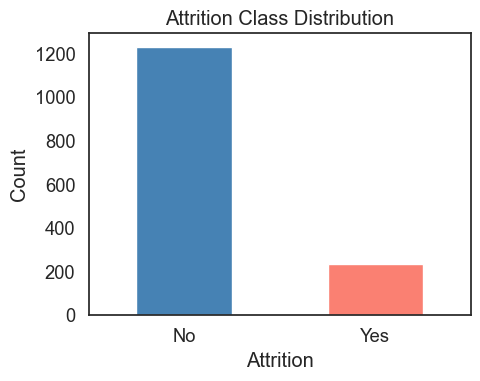

In [15]:
# Visualize class distribution of the target variable
fig, ax = plt.subplots(figsize=(5, 4))
df['Attrition'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Attrition Class Distribution')
ax.set_xlabel('Attrition')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

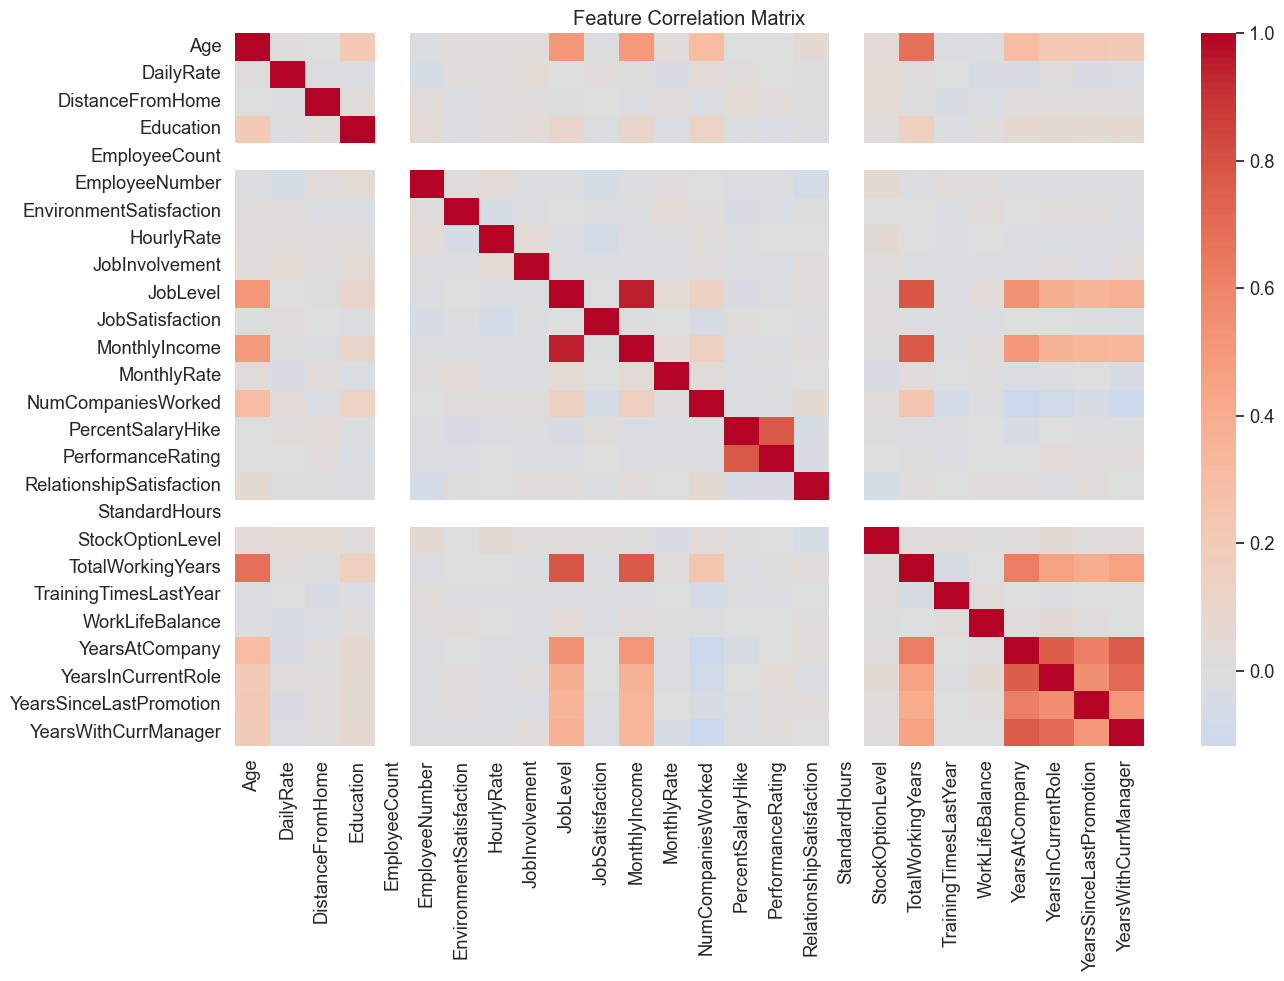

In [16]:
# Correlation heatmap of numerical features — helps identify redundant or strongly related variables
# Key observations:
# - 'EmployeeCount' and 'StandardHours' show no correlation -> constant columns, drop them
# - 'TotalWorkingYears', 'JobLevel', 'MonthlyIncome' are highly correlated -> potential redundancy
# - 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
#   form a highly correlated cluster -> consider keeping only one or using PCA
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=False,
    cmap='coolwarm',
    center=0
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

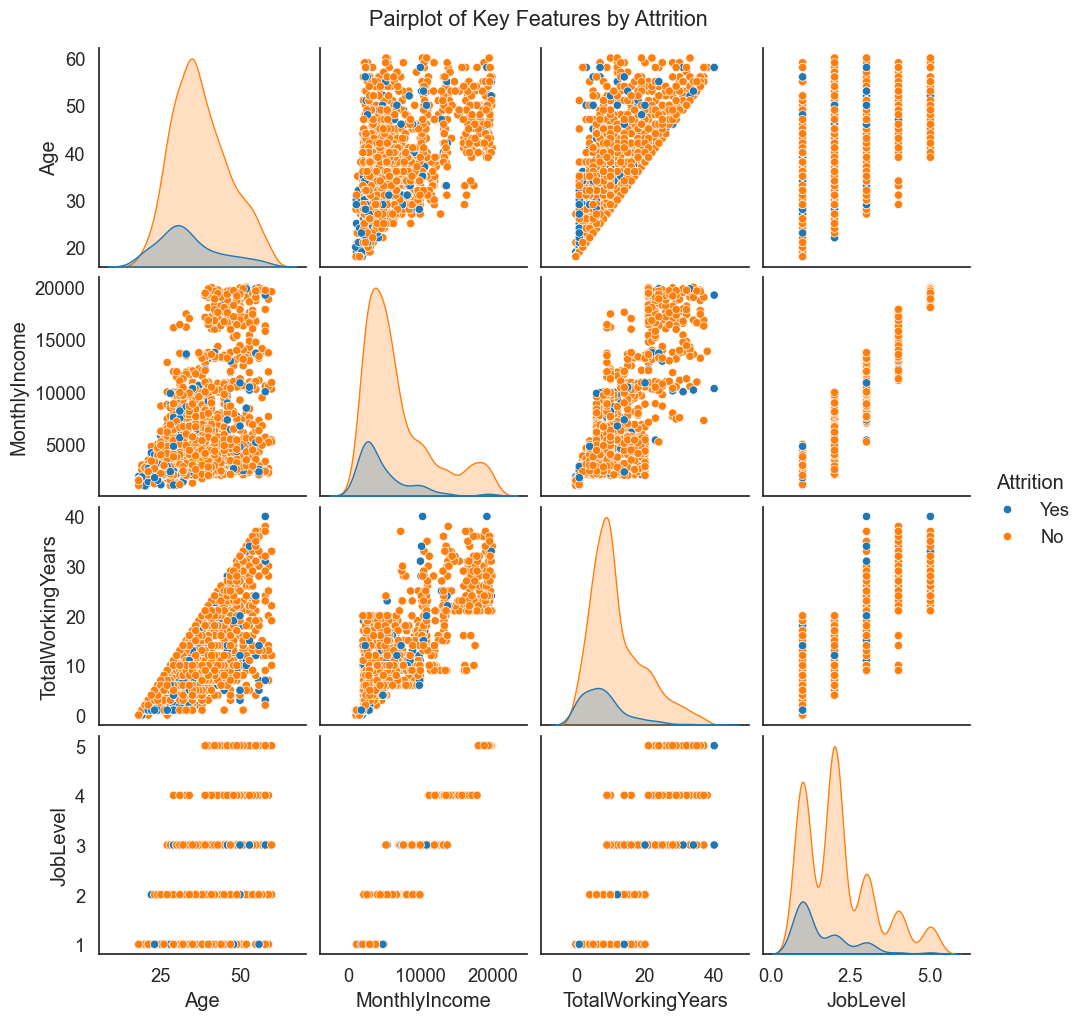

In [17]:
# Pairplot of most relevant features colored by target variable
plot_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'JobLevel', 'Attrition']
sns.pairplot(df[plot_cols], hue='Attrition', palette='tab10')
plt.suptitle('Pairplot of Key Features by Attrition', y=1.02)
plt.show()

# 3. Data Preprocessing

In [18]:
# Drop constant columns — zero variance, no predictive value
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'EmployeeNumber','Over18'])
print(f'Shape after dropping constant/ID columns: {df.shape}')

Shape after dropping constant/ID columns: (1470, 31)


In [19]:
# Encode the target variable: Yes -> 1, No -> 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print('Target encoding:', df['Attrition'].value_counts().to_dict())

Target encoding: {0: 1233, 1: 237}


In [20]:
# Identify categorical columns and encode them with LabelEncoder
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('✅ Categorical encoding done.')

Categorical columns (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
✅ Categorical encoding done.


In [21]:
# Separate features (X) and target (y)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')

Features shape: (1470, 30)
Target shape:   (1470,)


In [22]:
# Train/validation/test split: 70% train, 15% val, 15% test — stratified to preserve class ratio
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train size: {X_train.shape[0]} samples')
print(f'Val size:   {X_val.shape[0]} samples')
print(f'Test size:  {X_test.shape[0]} samples')

Train size: 1029 samples
Val size:   220 samples
Test size:  221 samples


In [23]:
# Normalize numerical features using StandardScaler
# Fit only on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('✅ Normalization done — scaler fitted on training set only.')

✅ Normalization done — scaler fitted on training set only.


## 3.1. Save Preprocessed Data

In [24]:
import numpy as np

# Save splits as numpy arrays for use in modelling notebook
np.save(os.path.join(OUTPUT_PATH, 'X_train.npy'), X_train_scaled)
np.save(os.path.join(OUTPUT_PATH, 'X_val.npy'),   X_val_scaled)
np.save(os.path.join(OUTPUT_PATH, 'X_test.npy'),  X_test_scaled)
np.save(os.path.join(OUTPUT_PATH, 'y_train.npy'), y_train.values)
np.save(os.path.join(OUTPUT_PATH, 'y_val.npy'),   y_val.values)
np.save(os.path.join(OUTPUT_PATH, 'y_test.npy'),  y_test.values)

print(f'✅ All splits saved to {OUTPUT_PATH}')

✅ All splits saved to c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\processed


## 3.2. Integration for DiCE Framework Approach:

- feature taxonomy: required step before any DiCE configuration (we need to define the characteristic of each feature)
- per feature distribution analysis: we need to check the feasible value range per feature as we cannot identify counterfactual contraints without knowing the domain of each variable

**Feature Taxonomy**

The features must be classified so we can later determine which variables will be used to generate the counterfactuals

- Immutable: features that cannot be changed in the counterfactual scenario
- Ordinal: feature ordered according to a discrete scale
- Nominal: unordered features
- Continuous: numeric features

In [25]:
print(X_train.columns)

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')


In [26]:
# Classify the features
immutabile_feature=[
    'Age',
    'EducationField', 'Gender','TotalWorkingYears'
]

ordinal_feature=['BusinessTravel', 'Education','EnvironmentSatisfaction','JobInvolvement', 'JobLevel','JobSatisfaction','PerformanceRating','RelationshipSatisfaction','StockOptionLevel','WorkLifeBalance' ]

nominal_feature=['Department','EducationField','Gender','JobRole','MaritalStatus','OverTime']
continuous_feature=['Age','DailyRate','DistanceFromHome', 'HourlyRate','MonthlyIncome','MonthlyRate','NumCompaniesWorked','PercentSalaryHike','TrainingTimesLastYear','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager' ]

print(f'Immutable features: {len(immutabile_feature)}')
print(f'Ordinal features: {len(ordinal_feature)}')
print(f'Nominal features: {len(nominal_feature)}')
print(f'Continuous features: {len(continuous_feature)}')


Immutable features: 4
Ordinal features: 10
Nominal features: 6
Continuous features: 13


YearsSinceLastPromotion    2.010895
YearsAtCompany             1.686200
MonthlyIncome              1.328611
NumCompaniesWorked         0.993086
DistanceFromHome           0.915862
YearsInCurrentRole         0.869674
PercentSalaryHike          0.825324
YearsWithCurrManager       0.774406
TrainingTimesLastYear      0.616180
Age                        0.424652
DailyRate                 -0.008171
HourlyRate                -0.008719
MonthlyRate               -0.012099
dtype: float64


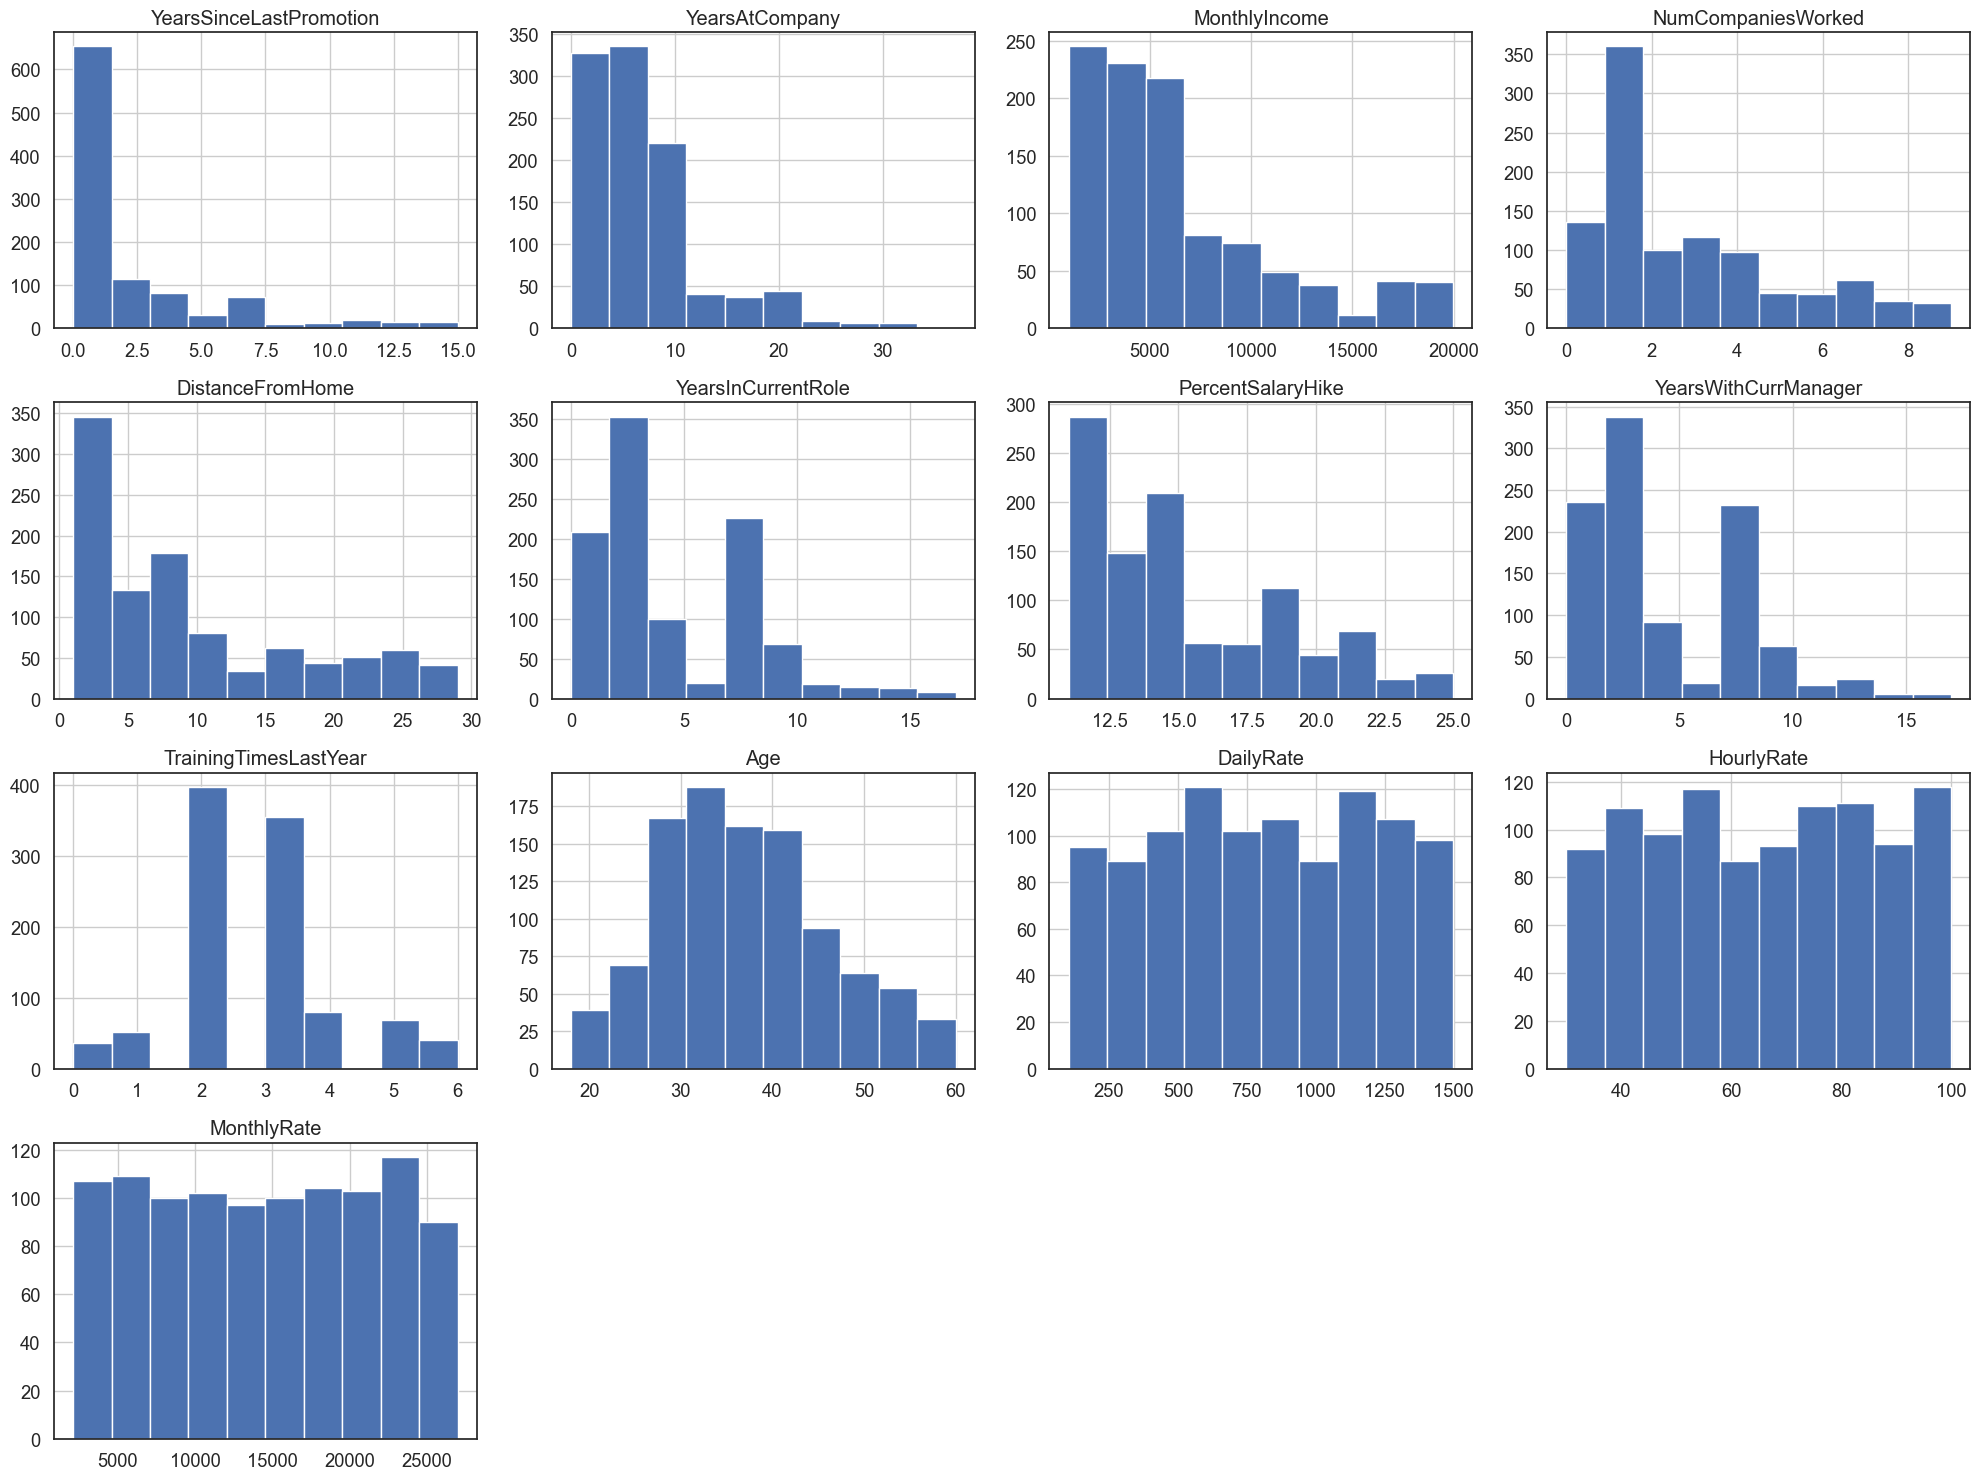

In [27]:
# Skewness audit
skew = X_train[continuous_feature].skew().sort_values(ascending=False)
#high_skew_cols = skew[skew.abs() > 0.75].index.tolist()
print(skew)


# Plot in skewness order
X_train[skew.index].hist(figsize=(20, 15))
plt.tight_layout()
plt.show()


For the feature 'DailyRate', 'HourlyRate','MonthlyRate', the skewness value is close to zero which indicates a almost perfect uniform distribution rather than a well behaved Gaussian. This means that these variables do know carry no natural signal so evry value in their range is equally likely regardless of attrition outcome. These variables may be dropped.



In [28]:
# Checking skewness
skew = X_train.skew().sort_values(ascending=False)
high_skew_cols = skew[skew.abs() > 0.75].index.tolist()
print(high_skew_cols)


['YearsSinceLastPromotion', 'PerformanceRating', 'YearsAtCompany', 'MonthlyIncome', 'TotalWorkingYears', 'NumCompaniesWorked', 'StockOptionLevel', 'JobLevel', 'DistanceFromHome', 'OverTime', 'YearsInCurrentRole', 'PercentSalaryHike', 'YearsWithCurrManager', 'BusinessTravel']


In [29]:
# Per Feature distribution
for c in cat_cols:
  print(df[c].value_counts())

BusinessTravel
2    1043
1     277
0     150
Name: count, dtype: int64
Department
1    961
2    446
0     63
Name: count, dtype: int64
EducationField
1    606
3    464
2    159
5    132
4     82
0     27
Name: count, dtype: int64
Gender
1    882
0    588
Name: count, dtype: int64
JobRole
7    326
6    292
2    259
4    145
0    131
3    102
8     83
5     80
1     52
Name: count, dtype: int64
MaritalStatus
1    673
2    470
0    327
Name: count, dtype: int64
OverTime
0    1054
1     416
Name: count, dtype: int64
